In [3]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# ---------------- داده‌ها ------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [5]:
# -------- آماده‌سازی داده برای Inception --------
def prepare_incep_dataset(x, y, batch_size=32):
    def preprocess(img, label):
        img = tf.image.resize(img, (299, 299))
        img = preprocess_input(img)
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_incep = prepare_incep_dataset(x_train, y_train_cat)
test_ds_incep = prepare_incep_dataset(x_test, y_test_cat)

In [6]:
# -------- مدل InceptionV3 --------
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # می‌تونی True بذاری برای Fine-tune

model_incep = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_incep.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
print("\n🔧 در حال آموزش مدل InceptionV3...")
model_incep.fit(train_ds_incep, epochs=5, verbose=2)
test_loss_incep, test_acc_incep = model_incep.evaluate(test_ds_incep, verbose=0)
print(f"\n✅ دقت InceptionV3: {test_acc_incep:.4f}")


🔧 در حال آموزش مدل InceptionV3...
Epoch 1/5
1563/1563 - 298s - loss: 0.6102 - accuracy: 0.8001 - 298s/epoch - 191ms/step
Epoch 2/5
1563/1563 - 292s - loss: 0.4819 - accuracy: 0.8386 - 292s/epoch - 187ms/step
Epoch 3/5
1563/1563 - 289s - loss: 0.4514 - accuracy: 0.8487 - 289s/epoch - 185ms/step
Epoch 4/5
1563/1563 - 288s - loss: 0.4223 - accuracy: 0.8565 - 288s/epoch - 184ms/step
Epoch 5/5
1563/1563 - 290s - loss: 0.4103 - accuracy: 0.8612 - 290s/epoch - 186ms/step

✅ دقت InceptionV3: 0.8686


313/313 [==============================] - 56s 175ms/step

📊 گزارش طبقه‌بندی InceptionV3:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1000
           1       0.90      0.94      0.92      1000
           2       0.88      0.83      0.85      1000
           3       0.77      0.81      0.79      1000
           4       0.89      0.78      0.83      1000
           5       0.85      0.82      0.83      1000
           6       0.86      0.89      0.88      1000
           7       0.86      0.90      0.88      1000
           8       0.91      0.92      0.92      1000
           9       0.94      0.87      0.90      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



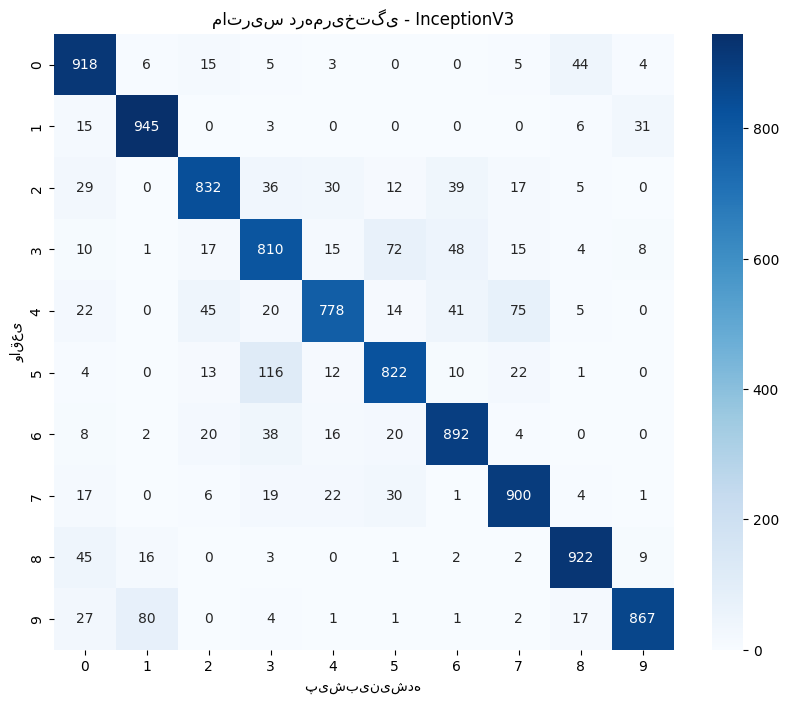

In [8]:
# پیش‌بینی و ارزیابی
y_pred_incep = model_incep.predict(test_ds_incep)
y_pred_classes_incep = np.argmax(y_pred_incep, axis=1)

print("\n📊 گزارش طبقه‌بندی InceptionV3:")
print(classification_report(y_test, y_pred_classes_incep))

conf_mat_incep = confusion_matrix(y_test, y_pred_classes_incep)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_incep, annot=True, fmt='d', cmap='Blues')
plt.title("ماتریس درهم‌ریختگی - InceptionV3")
plt.xlabel("پیش‌بینی‌شده")
plt.ylabel("واقعی")
plt.show()

In [9]:
# -------- مدل CNN ساده --------
x_train_small = x_train / 255.0
x_test_small = x_test / 255.0

model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
print("\n🔧 در حال آموزش مدل CNN ساده...")
model_cnn.fit(x_train_small, y_train_cat, epochs=5, batch_size=32, validation_split=0.1, verbose=2)
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_small, y_test_cat, verbose=0)
print(f"\n✅ دقت CNN ساده: {test_acc_cnn:.4f}")


🔧 در حال آموزش مدل CNN ساده...
Epoch 1/5
1407/1407 - 5s - loss: 1.4813 - accuracy: 0.4660 - val_loss: 1.2209 - val_accuracy: 0.5668 - 5s/epoch - 3ms/step
Epoch 2/5
1407/1407 - 3s - loss: 1.1341 - accuracy: 0.6022 - val_loss: 1.0869 - val_accuracy: 0.6194 - 3s/epoch - 2ms/step
Epoch 3/5
1407/1407 - 3s - loss: 0.9977 - accuracy: 0.6523 - val_loss: 0.9873 - val_accuracy: 0.6642 - 3s/epoch - 2ms/step
Epoch 4/5
1407/1407 - 3s - loss: 0.9095 - accuracy: 0.6843 - val_loss: 0.9395 - val_accuracy: 0.6744 - 3s/epoch - 2ms/step
Epoch 5/5
1407/1407 - 3s - loss: 0.8433 - accuracy: 0.7048 - val_loss: 0.9244 - val_accuracy: 0.6826 - 3s/epoch - 2ms/step

✅ دقت CNN ساده: 0.6778


313/313 [==============================] - 1s 2ms/step

📊 گزارش طبقه‌بندی CNN ساده:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      1000
           1       0.83      0.76      0.79      1000
           2       0.60      0.52      0.56      1000
           3       0.47      0.54      0.50      1000
           4       0.58      0.66      0.62      1000
           5       0.67      0.50      0.57      1000
           6       0.64      0.85      0.73      1000
           7       0.76      0.70      0.73      1000
           8       0.77      0.82      0.79      1000
           9       0.84      0.66      0.74      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



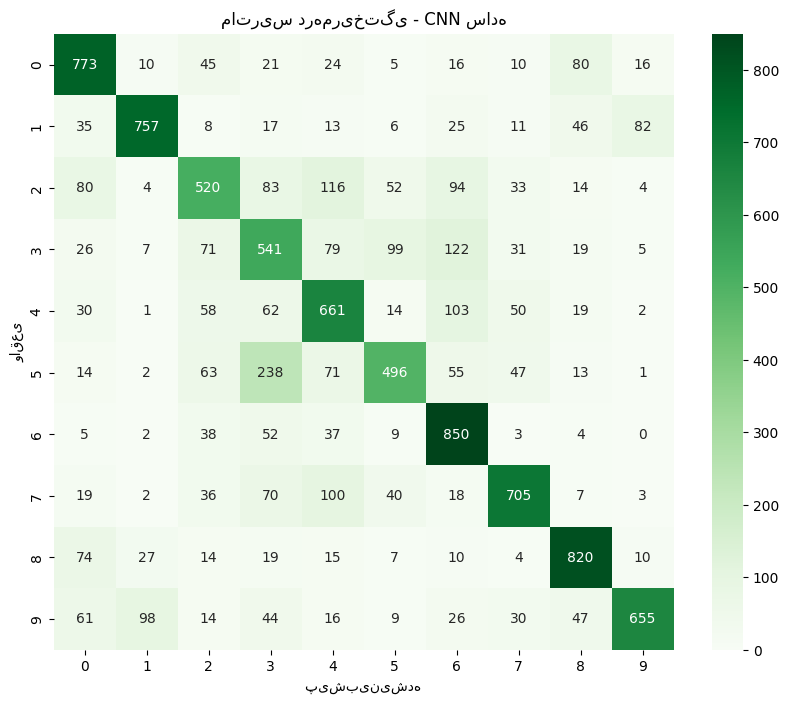

In [11]:
# پیش‌بینی و ارزیابی
y_pred_cnn = model_cnn.predict(x_test_small)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)

print("\n📊 گزارش طبقه‌بندی CNN ساده:")
print(classification_report(y_test, y_pred_classes_cnn))

conf_mat_cnn = confusion_matrix(y_test, y_pred_classes_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_cnn, annot=True, fmt='d', cmap='Greens')
plt.title("ماتریس درهم‌ریختگی - CNN ساده")
plt.xlabel("پیش‌بینی‌شده")
plt.ylabel("واقعی")
plt.show()

In [12]:
# -------- مقایسه نهایی --------
print("\n📈 مقایسه دقت دو مدل:")
print(f"✔️ InceptionV3 Accuracy: {test_acc_incep:.4f}")
print(f"✔️ Simple CNN Accuracy : {test_acc_cnn:.4f}")


📈 مقایسه دقت دو مدل:
✔️ InceptionV3 Accuracy: 0.8686
✔️ Simple CNN Accuracy : 0.6778
